# UA Advanced Chapter 1 — Milan Original Retype

This notebook is intentionally a blank retyping workspace. Open your purchased `Chapter_01_Setting_Up.ipynb` beside it and type each cell yourself. Do not copy and paste the course notebook into this repository.

## 1.1 Setting Up the Environment

Retype Milan's environment and import cells below.

In [1]:
import warnings
warnings.filterwarnings('ignore')

# OSM access
import osmnx as ox

# Geospatial data handling
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box

# Plotting
import matplotlib.pyplot as plt
import contextily as cx

print(f"✓ geopandas {gpd.__version__}")
print(f"✓ osmnx     {ox.__version__}")

✓ geopandas 1.1.4
✓ osmnx     2.1.1


## 1.2 The Study-Area Pattern

Retype Milan's configuration, boundary resolution, projection, and boundary plot cells below.

In [4]:
PLACE          = "Manhattan, New York"
CRS_METRIC     = 32618        # WGS 84 / UTM 18N — meters, correct for Manhattan
CRS_GEOGRAPHIC = 4326         # WGS 84 — degrees; the CRS OSM data arrives in

In [8]:
from pathlib import Path
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print(f"✓ Study area : {PLACE}")
print(f"✓ Metric CRS : EPSG:{CRS_METRIC}")
print(f"✓ Data dir   : {DATA_DIR}/")

✓ Study area : Manhattan, New York
✓ Metric CRS : EPSG:32618
✓ Data dir   : data/


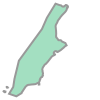

In [11]:
admin_gdf = ox.geocode_to_gdf(PLACE)
admin_poly = admin_gdf.geometry.union_all()

admin_poly

In [17]:
admin_gdf_metric = admin_gdf.to_crs(epsg=CRS_METRIC)
study_area = admin_gdf_metric.geometry.union_all()
admin_gdf_metric
admin_gdf_metric.crs
print(f"  administrative polygon (incl. water): {study_area.area / 1e6:,.1f} km²")

  administrative polygon (incl. water): 86.7 km²


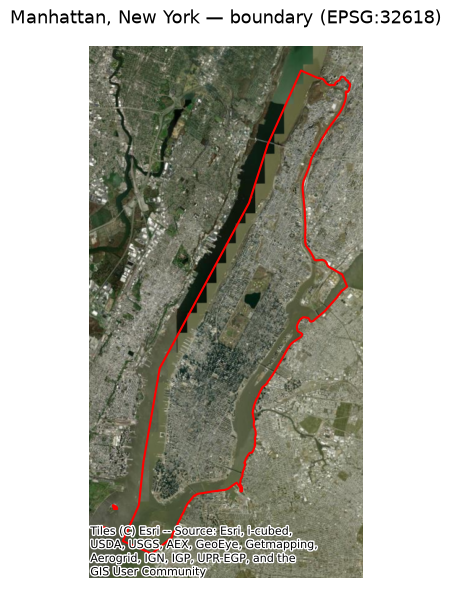

In [18]:
f, ax = plt.subplots(1, 1, figsize=(6, 6))
admin_gdf_metric.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1.5)
cx.add_basemap(ax, crs=admin_gdf_metric.crs, source=cx.providers.Esri.WorldImagery)

ax.set_title(f'{PLACE} — boundary (EPSG:{CRS_METRIC})', fontsize=13)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

## 1.3 Base Geometry

- OSM coverage is a lowerbound - not everybuilding is mapped
- a footprint is groundfloow area not floor space

In [20]:
buildings = ox.features_from_polygon(admin_poly, tags={"building": True})


In [21]:
buildings = buildings.reset_index()
if "id" in buildings.columns:
    buildings = buildings.rename(columns={"id": "osmid"})

print("index moved into colums")
                                

index moved into colums


In [22]:
is_polygon = buildings.geometry.type.isin(["Polygon", "MultiPolygon"])
buidings = buildings[is_polygon].copy()
buildings = buildings.to_crs(epsg=CRS_METRIC)

In [23]:
print(f"✓ Kept polygonal footprints and projected to EPSG:{CRS_METRIC}")
print(f"  footprints: {len(buildings):,}")

✓ Kept polygonal footprints and projected to EPSG:32618
  footprints: 46,319
